In [7]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
#Importing CSV file
df_choc = pd.read_csv('Chocolate Sales.csv')

In [9]:
df_choc.head(10)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04-Jan-22,"$5,320",180
1,Van Tuxwell,India,85% Dark Bars,01-Aug-22,"$7,896",94
2,Gigi Bohling,India,Peanut Butter Cubes,07-Jul-22,"$4,501",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27-Apr-22,"$12,726",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24-Feb-22,"$13,685",184
5,Van Tuxwell,India,Smooth Sliky Salty,06-Jun-22,"$5,376",38
6,Oby Sorrel,UK,99% Dark & Pure,25-Jan-22,"$13,685",176
7,Gunar Cockshoot,Australia,After Nines,24-Mar-22,"$3,080",73
8,Jehu Rudeforth,New Zealand,50% Dark Bites,20-Apr-22,"$3,990",59
9,Brien Boise,Australia,99% Dark & Pure,04-Jul-22,"$2,835",102


In [10]:
df_choc.shape

(1094, 6)

In [11]:
df_choc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   1094 non-null   object
 1   Country        1094 non-null   object
 2   Product        1094 non-null   object
 3   Date           1094 non-null   object
 4   Amount         1094 non-null   object
 5   Boxes Shipped  1094 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 51.4+ KB


In [12]:
#Changing type and format of Date Column
df_choc['Date'] = pd.to_datetime(df_choc['Date'], format='%d-%b-%y')

#Removing "$" and "," and "spaces" and changing type into float of amount column
df_choc['Amount'] = df_choc['Amount'].str.replace('$', '', regex=False).str.replace(',','', regex=False).str.strip().astype(float)

In [13]:
df_choc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   1094 non-null   object        
 1   Country        1094 non-null   object        
 2   Product        1094 non-null   object        
 3   Date           1094 non-null   datetime64[ns]
 4   Amount         1094 non-null   float64       
 5   Boxes Shipped  1094 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 51.4+ KB


In [14]:
df_choc.sample(5)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
279,Karlen McCaffrey,India,Orange Choco,2022-06-27,3122.0,149
312,Curtice Advani,UK,White Choc,2022-02-01,1540.0,73
406,Ches Bonnell,Canada,Spicy Special Slims,2022-08-05,5327.0,183
181,Kaine Padly,Canada,Peanut Butter Cubes,2022-07-04,3269.0,176
882,Oby Sorrel,USA,Milk Bars,2022-06-14,1736.0,79


In [15]:
df_choc.isnull().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

In [16]:
df_choc.duplicated().sum()

np.int64(0)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9888\337925736.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_sales,x='Amount', y='Country', palette='viridis')


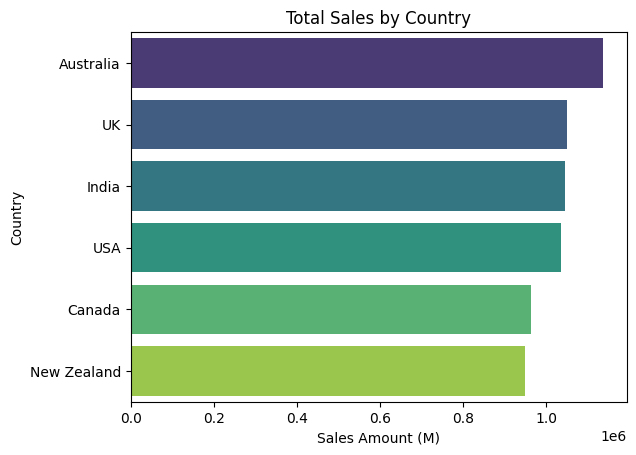

In [17]:
# Sales by Country
country_sales = df_choc.groupby('Country')['Amount'].sum().sort_values(ascending=False).reset_index()

plt.Figure(figsize=(10,6))
sns.barplot(data=country_sales,x='Amount', y='Country', palette='viridis')
plt.title('Total Sales by Country')
plt.xlabel('Sales Amount (M)')
plt.ylabel('Country')
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9888\2517355202.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_salespeople, x='Amount', y='Sales Person', palette='coolwarm')


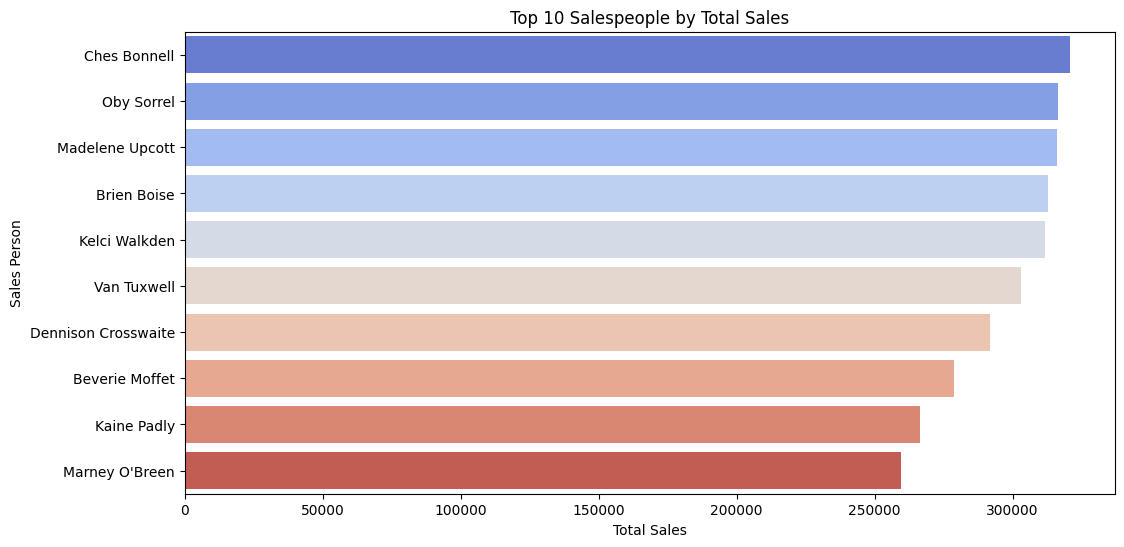

In [18]:
# Salesperson Performance
top_salespeople = df_choc.groupby('Sales Person')['Amount'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=top_salespeople, x='Amount', y='Sales Person', palette='coolwarm')
plt.title('Top 10 Salespeople by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Sales Person')
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9888\446920064.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_per_box, x='Revenue per Box', y='Product', palette='cubehelix')


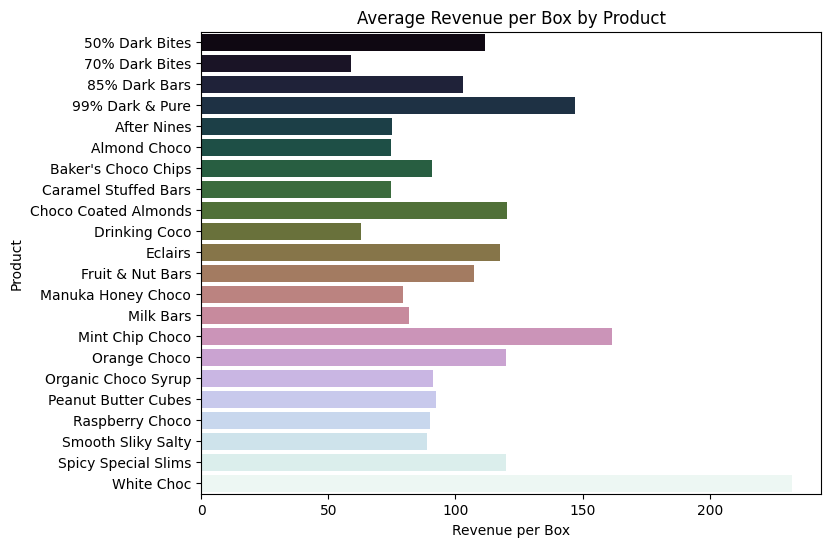

In [19]:
# Average Sale per Box by Product
df_choc['Revenue per Box'] = df_choc['Amount']/df_choc['Boxes Shipped']
avg_per_box = df_choc.groupby('Product')['Revenue per Box'].mean().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=avg_per_box, x='Revenue per Box', y='Product', palette='cubehelix')
plt.title('Average Revenue per Box by Product')
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9888\2526051827.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_boxes, y='Boxes Shipped', x='Country', palette='magma')


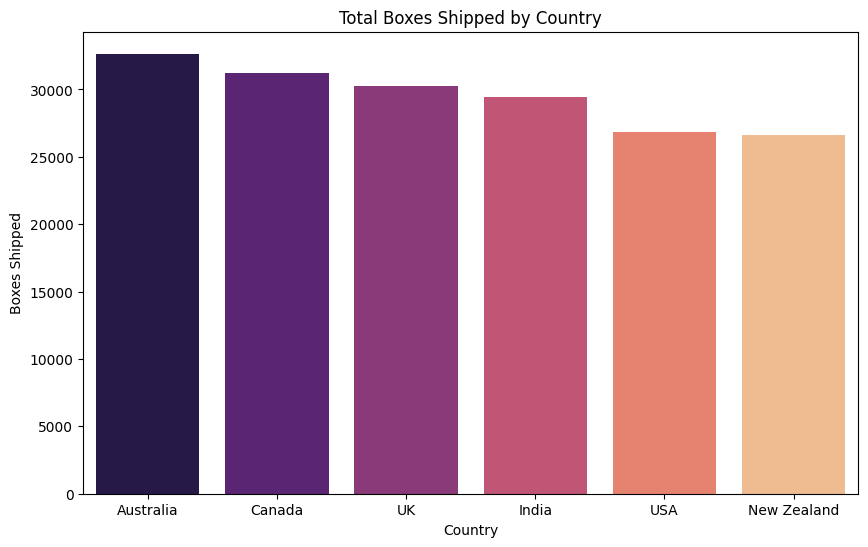

In [20]:
# Total Boxes Shipped by Country
country_boxes = df_choc.groupby('Country')['Boxes Shipped'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=country_boxes, y='Boxes Shipped', x='Country', palette='magma')
plt.title('Total Boxes Shipped by Country')
plt.xlabel('Country')
plt.ylabel('Boxes Shipped')
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9888\1868156765.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_choc, x='Product', y='Amount', palette='Set2')


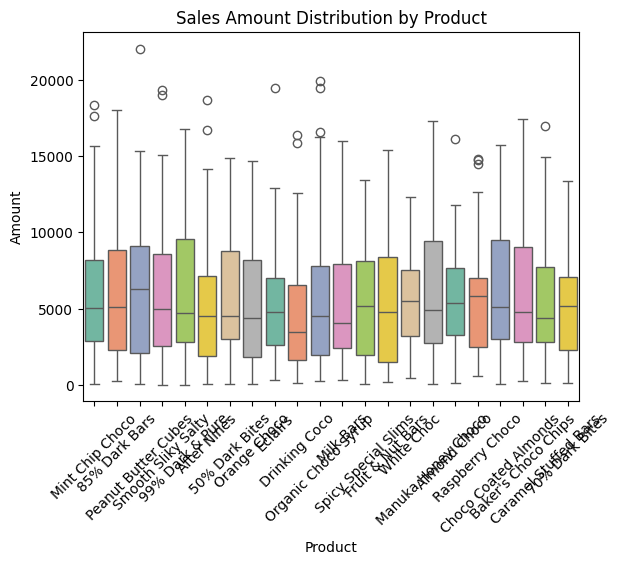

In [21]:
# Product Sales Distribution
plt.Figure(figsize=(10,6))
sns.boxplot(data=df_choc, x='Product', y='Amount', palette='Set2')
plt.title('Sales Amount Distribution by Product')
plt.xticks(rotation=45)
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9888\1858455445.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_choc, x='Sales Person', y='Amount', palette='Set3')


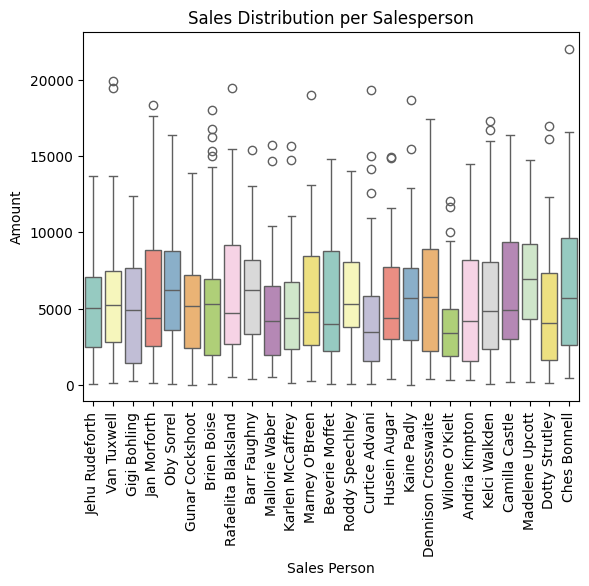

In [ ]:
# Sales Distribution per Salesperson

plt.Figure(figsize=(14,6))
sns.boxplot(data=df_choc, x='Sales Person', y='Amount', palette='Set3')
plt.title('Sales Distribution per Salesperson')
plt.xticks(rotation = 90)
plt.show() 

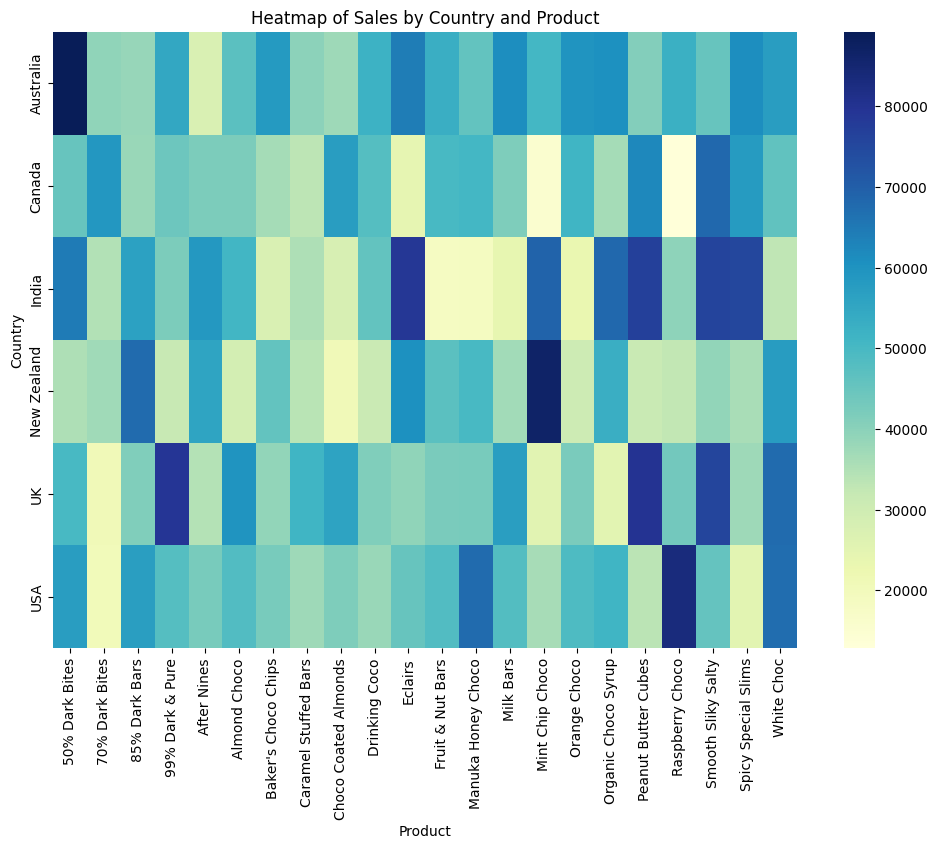

In [24]:
# Sales Heatmap by Country & Product
pivot = df_choc.pivot_table(index='Country', columns='Product', values='Amount', aggfunc='sum').fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=False, fmt='.0f', cmap='YlGnBu')
plt.title('Heatmap of Sales by Country and Product')
plt.xlabel('Product')
plt.ylabel('Country')
plt.show()
